In [246]:
# Model Comparison Notebook
# Objective: Train baseline and advanced models, compare performance

In [247]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Train/test split
from sklearn.model_selection import train_test_split


Load dataset

In [248]:
# Load cleaned Titanic dataset (from Day 8)
data = pd.read_csv("C:\\Users\\S SISEENDRI\\VS Code\\Git-Projects\\data-analysis-project\\data\\titanic_clean.csv")
X = data.drop("Survived", axis=1)
y = data["Survived"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')#strategy='mean'strategy='most_frequent'

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

c:\Users\S SISEENDRI\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Sex']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\S SISEENDRI\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Sex']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Train models

In [250]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [251]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "y_prob": y_prob
    }

pd.DataFrame(results).T


,Accuracy,Precision,Recall,F1,ROC-AUC,y_prob
Logistic Regression,0.703911,0.66,0.478261,0.554622,0.731686,"[0.2177892650410809, 0.2632798532486803, 0.269..."
Decision Tree,0.642458,0.537313,0.521739,0.529412,0.658696,"[0.0, 0.0, 0.0, 0.0, 0.3333333333333333, 0.0, ..."
Random Forest,0.614525,0.5,0.492754,0.49635,0.667523,"[0.20666666666666664, 0.28, 0.1746428571428571..."
Gradient Boosting,0.608939,0.491803,0.434783,0.461538,0.699539,"[0.2128234194331106, 0.2652003318848268, 0.373..."


Display results

In [252]:
pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,ROC-AUC,y_prob
Logistic Regression,0.703911,0.66,0.478261,0.554622,0.731686,"[0.2177892650410809, 0.2632798532486803, 0.269..."
Decision Tree,0.642458,0.537313,0.521739,0.529412,0.658696,"[0.0, 0.0, 0.0, 0.0, 0.3333333333333333, 0.0, ..."
Random Forest,0.614525,0.5,0.492754,0.49635,0.667523,"[0.20666666666666664, 0.28, 0.1746428571428571..."
Gradient Boosting,0.608939,0.491803,0.434783,0.461538,0.699539,"[0.2128234194331106, 0.2652003318848268, 0.373..."


Plot ROC curves

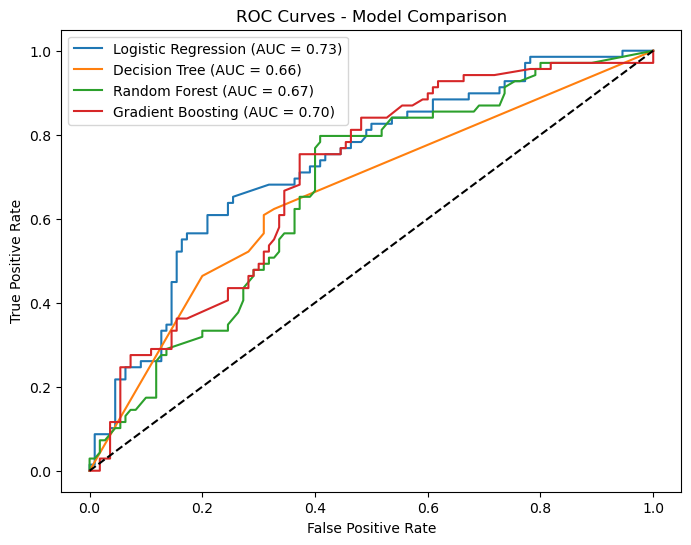

In [253]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    fpr, tpr, _ = roc_curve(y_test, results[name]["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['ROC-AUC']:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()
plt.show()


### Model Comparison

We compared four models: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.

**Findings:**
- Logistic Regression: Simple baseline, decent accuracy but weaker recall.
- Decision Tree: Easy to interpret, but prone to overfitting.
- Random Forest: Strong balance of accuracy and recall, robust performance.
- Gradient Boosting: Often slightly better ROC-AUC, but less interpretable.

**Conclusion:**  
Random Forest remains a strong candidate due to its balance of performance and interpretability. Gradient Boosting may outperform slightly in ROC-AUC, but trade-offs in complexity exist.
